In [1]:
import numpy as np
import pandas as pd
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
from keras import layers
from sklearn.preprocessing import StandardScaler
import numpy as np
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from metrics_tracking import F1Score, plot_metrics


In [2]:
#import the datasets to test
def load_data(data_file_name):
    data = np.load(f"Preprocessed_Data/{data_file_name}")
    # Access arrays by their keys
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]
    X_train = X_train[..., :-1] #TEMP FIX REMOVE LATER - FIX PREPROCESSING TO GET RID OF STRING COLUMN
    X_test  = X_test[..., :-1] #TEMP FIX REMOVE LATER
    print(X_train.shape)
    print(y_train.shape)
    print(X_test.shape)
    print(y_test.shape)
    data.close()
    return X_train, y_train, X_test, y_test

data_file_name = "roads_canids_windows_200hz_3s.npz"
X_train, y_train, X_test, y_test = load_data(data_file_name)

(11280, 600, 23)
(11280,)
(13948, 600, 23)
(13948,)


In [3]:
def standardize(X_train, y_train, X_test, y_test):
    # Clip outliers 
    X_train = np.clip(X_train, -1e6, 1e6)
    X_test  = np.clip(X_test,  -1e6, 1e6)
    # Standardize features
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat  = X_test.reshape(-1,  X_test.shape[-1])
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)
    X_train = X_train_scaled.reshape(X_train.shape)
    X_test  = X_test_scaled.reshape(X_test.shape)
    return X_train, y_train, X_test, y_test
X_train, y_train, X_test, y_test = standardize(X_train, y_train, X_test, y_test)

KeyboardInterrupt: 

In [5]:
def create_model_road(): #this is the same model we'll always use for all. 
    model = keras.Sequential()
    model.add(layers.Input(shape=(600, 23)))
    # model.add(layers.Conv1D(128, 8, activation='relu'))
    model.add(layers.Conv1D(32, 4, activation='relu'))
    model.add(layers.GlobalAveragePooling1D()) #was GlobalMaxPooling1D
    model.add(layers.Dense(1, activation='sigmoid')) #output 1 bc we only have 2 labels: attack or not attack
    return model
model = create_model_road()

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 597, 32)        │         2,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#train data 
b_size = 32
callbacks = [
    ModelCheckpoint("saved_models/model_road_32cnn_stm32_chkpt.keras", monitor='val_auc', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=8, min_lr=1e-11, verbose=1),
    EarlyStopping(monitor='val_auc', patience=15, verbose=1, restore_best_weights=True)
]
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss = 'binary_crossentropy', 
              metrics = ['accuracy', keras.metrics.AUC(name='auc'), 
              keras.metrics.Precision(name='precision'),
              keras.metrics.Recall(name='recall'),
              F1Score(name="f1")
])
history = model.fit(X_train, y_train, batch_size = b_size, epochs = 50, validation_split=0.1, callbacks = callbacks, verbose = 1)

Epoch 1/50
309/318 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8539 - auc: 0.8260 - f1: 0.1722 - loss: 0.3259 - precision: 0.1594 - recall: 0.2909
Epoch 1: val_auc improved from None to 0.73818, saving model to saved_models/model_road_32cnn_stm32_chkpt.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9243 - auc: 0.8952 - f1: 0.1616 - loss: 0.1925 - precision: 0.2176 - recall: 0.1285 - val_accuracy: 0.6232 - val_auc: 0.7382 - val_f1: 0.2784 - val_loss: 0.7011 - val_precision: 0.8283 - val_recall: 0.1673 - learning_rate: 0.0010
Epoch 2/50
312/318 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9592 - auc: 0.9755 - f1: 0.4978 - loss: 0.0930 - precision: 0.7279 - recall: 0.3805
Epoch 2: val_auc improved from 0.73818 to 0.77906, saving model to saved_models/model_road_32cnn_stm32_chkpt.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9600 - auc: 0.9785 - f1: 0.5606 - loss: 0.0908 - precision: 0.7443 - recall: 0.4497 - val_accuracy: 0.6631 - val_auc: 0.7791 - val_f1

In [9]:
def print_test_metrics(X_test, y_test, model):
    testing_acc = model.evaluate(X_test,y_test, verbose=1)
    print(f"Test loss: {testing_acc[0]}")
    print(f"Test accuracy: {testing_acc[1]}")
    print(f"Test AUC: {testing_acc[2]}")
    print(f"Test Precision: {testing_acc[3]}")
    print(f"Test Recall: {testing_acc[4]}")
    print(f"Test F1: {testing_acc[5]}")
print_test_metrics(X_test, y_test, model)

436/436 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9902 - auc: 0.9078 - f1: 0.7364 - loss: 0.0545 - precision: 0.8796 - recall: 0.6333                
Test loss: 0.05445777252316475
Test accuracy: 0.990249514579773
Test AUC: 0.9077720046043396
Test Precision: 0.8796296119689941
Test Recall: 0.6333333253860474
Test F1: 0.7364340424537659


In [8]:
model_save_name = "stm32_ROAD_model32_final.keras"
model.save(f"saved_models/{model_save_name}")

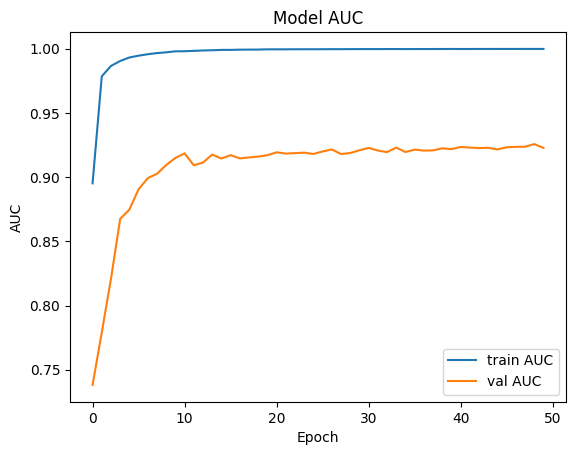

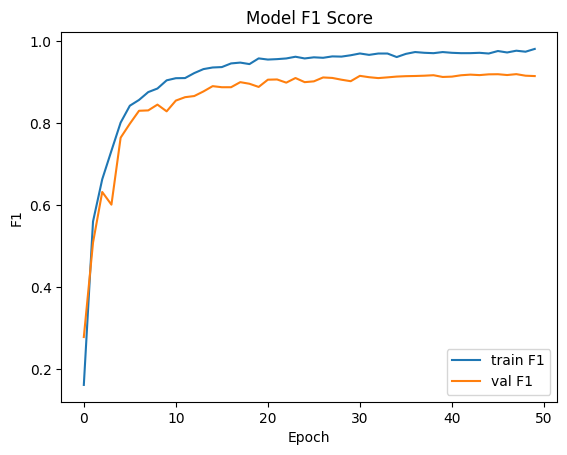

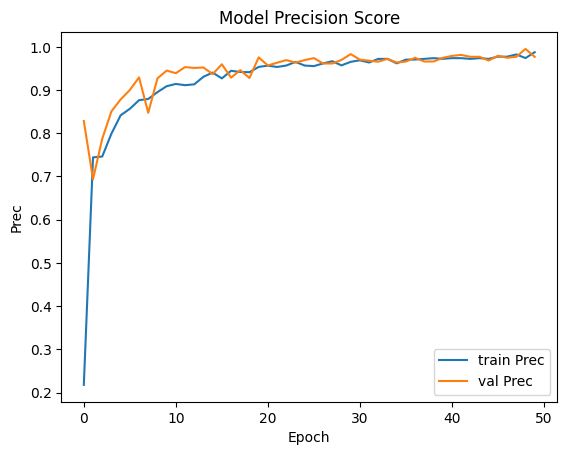

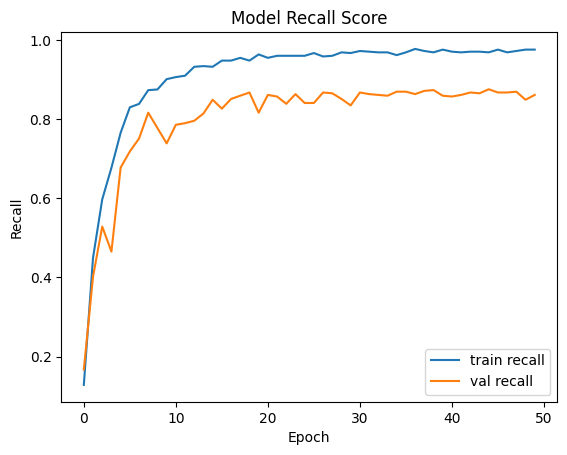

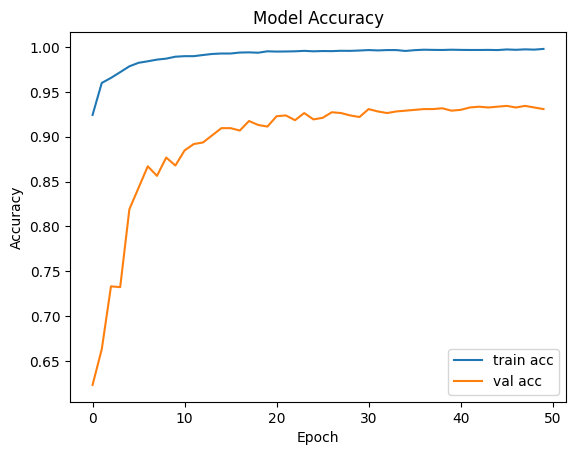

In [9]:
plot_metrics(history, model_save_name)
# plt.plot(history.history['accuracy'], label='train acc')
# plt.plot(history.history['val_accuracy'], label='val acc')
# plt.title('Model Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.show()

In [11]:
def print_report_and_score(model, X_test, y_test):
    y_pred_probs = model.predict(X_test).ravel()     # shape: (N,)
    y_pred = (y_pred_probs >= 0.5).astype(int)       # threshold
    print(classification_report(y_test, y_pred, target_names=["Ambient", "Attack"]))
    # --- Correct ROC-AUC for binary classifier ---
    roc_auc = roc_auc_score(y_test, y_pred_probs)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    return y_pred
y_pred = print_report_and_score(model, X_test, y_test)

436/436 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

     Ambient       0.99      1.00      0.99     13648
      Attack       0.99      0.54      0.70       300

    accuracy                           0.99     13948
   macro avg       0.99      0.77      0.85     13948
weighted avg       0.99      0.99      0.99     13948

ROC AUC Score: 0.9933


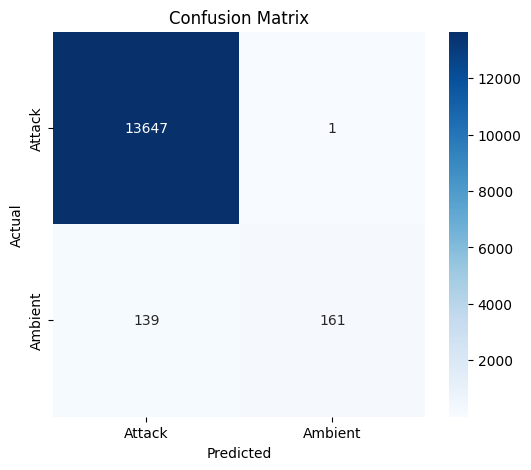

<Figure size 640x480 with 0 Axes>

In [12]:
def display_confusion_matrix(y_test, y_pred, model_name="best_ROAD_model128.keras"):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["Attack", "Ambient"],
        yticklabels=["Attack", "Ambient"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    plt.savefig(f"{model_name}_confusion_matrix.png")
display_confusion_matrix(y_test, y_pred, model_save_name)

436/436 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


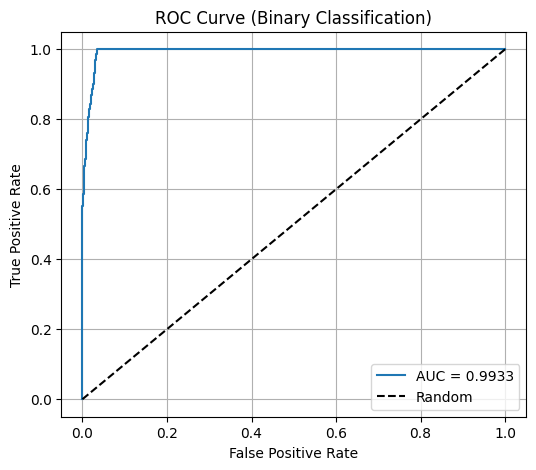

In [13]:
from sklearn.metrics import roc_curve
y_pred_proba = model.predict(X_test).ravel()   # shape (N,)
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [16]:
keras_model = keras.models.load_model( #import model for quantization
    # "saved_models/best_model_road_128cnn.keras",
    f"saved_models/{model_save_name}",
    compile=True,
    custom_objects={"F1Score": F1Score},
    safe_mode=False
)
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 597, 32)        │         2,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,029 (35.27 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,020 (23.52 KB)

In [18]:
import tensorflow as tf
def compress_model(keras_model, model_save_name, quantizefp16=False, quantizeint8=False, representative_data_gen=None):
    model_save_name = model_save_name.replace(".keras", "")
    if quantizeint8:
        tflite_save_name = f"saved_models/TFLite/{model_save_name}_int8.tflite"
    elif quantizefp16:
        tflite_save_name = f"saved_models/TFLite/{model_save_name}_fp16.tflite"
    else:
        tflite_save_name = f"saved_models/TFLite/{model_save_name}.tflite"

    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    if quantizefp16 and not quantizeint8:
        converter.target_spec.supported_types = [tf.float16]

    if quantizeint8:
        converter.representative_dataset = representative_data_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    with open(tflite_save_name, "wb") as f:
        f.write(tflite_model)
    return tflite_save_name
compress_model(keras_model, model_save_name)#

INFO:tensorflow:Assets written to: C:\Users\cyrus\AppData\Local\Temp\tmpoixro6ad\assets


INFO:tensorflow:Assets written to: C:\Users\cyrus\AppData\Local\Temp\tmpoixro6ad\assets


Saved artifact at 'C:\Users\cyrus\AppData\Local\Temp\tmpoixro6ad'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 600, 23), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  3082967959696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3082967961808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3082967962192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3082948405840: TensorSpec(shape=(), dtype=tf.resource, name=None)


'saved_models/TFLite/stm32_ROAD_model32_final.tflite'

In [51]:
def representative_data_gen():
    for i in range(200):                    
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

In [52]:
#int8 quantization
tflite_path = compress_model(
    keras_model,
    model_save_name=model_save_name,
    quantizefp16=False,
    quantizeint8=True,
    representative_data_gen=representative_data_gen
)

INFO:tensorflow:Assets written to: C:\Users\Cyrus\AppData\Local\Temp\tmpuvdg2a62\assets


INFO:tensorflow:Assets written to: C:\Users\Cyrus\AppData\Local\Temp\tmpuvdg2a62\assets


Saved artifact at 'C:\Users\Cyrus\AppData\Local\Temp\tmpuvdg2a62'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 600, 23), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2812854454992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456912: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\Cyrus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [48]:
#test fp16 model to see if it destroyed performance
def evaluate_tflite_auc(model_path, x_data, y_labels):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_det = interpreter.get_input_details()
    output_det = interpreter.get_output_details()
    in_dtype = input_det[0]['dtype']
    y_probs = []
    for i in range(len(X_test)):
        sample = X_test[i:i+1].astype(np.float32)
        if in_dtype == np.int8:
            scale, zp = input_det[0]['quantization']
            sample = (sample / scale + zp).round().astype(np.int8)
        interpreter.set_tensor(input_det[0]['index'], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_det[0]['index'])
        if output_det[0]['dtype'] == np.int8:
            s, z = output_det[0]['quantization']
            output = (output.astype(np.float32) - z) * s
        y_probs.append(output[0][0])
    return roc_auc_score(y_test, y_probs)

In [53]:
fp32 = compress_model(keras_model, model_save_name, quantizefp16=False, quantizeint8=False)
int8 = compress_model(keras_model, model_save_name, quantizefp16=False, quantizeint8=True, representative_data_gen=representative_data_gen)

print("FP32:", evaluate_tflite_auc(fp32, X_test, y_test))
print("INT8:", evaluate_tflite_auc(int8, X_test, y_test))

INFO:tensorflow:Assets written to: C:\Users\Cyrus\AppData\Local\Temp\tmpbgkvcrok\assets


INFO:tensorflow:Assets written to: C:\Users\Cyrus\AppData\Local\Temp\tmpbgkvcrok\assets


Saved artifact at 'C:\Users\Cyrus\AppData\Local\Temp\tmpbgkvcrok'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 600, 23), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2812854454992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456912: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: C:\Users\Cyrus\AppData\Local\Temp\tmpdm2nkf7u\assets


INFO:tensorflow:Assets written to: C:\Users\Cyrus\AppData\Local\Temp\tmpdm2nkf7u\assets


Saved artifact at 'C:\Users\Cyrus\AppData\Local\Temp\tmpdm2nkf7u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 600, 23), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2812854454992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2812854456912: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\Cyrus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
c:\Users\Cyrus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


FP32: 0.9804338853067605


c:\Users\Cyrus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8: 0.9804338853067605


In [55]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_auc_score

tflite_int8_save_name = f"saved_models/TFLite/{model_save_name}_int8.tflite"
tflite_int8_save_name = tflite_int8_save_name.replace(".keras", "")
# Load INT8 TFLite model
interpreter_int8 = tf.lite.Interpreter(model_path=tflite_int8_save_name)
interpreter_int8.allocate_tensors()
input_det = interpreter_int8.get_input_details()
output_det = interpreter_int8.get_output_details()

# FP32 predictions
y_probs_fp32 = keras_model.predict(X_test).ravel()

# INT8 predictions
y_probs_int8 = np.zeros_like(y_probs_fp32)
for i in range(len(X_test)):
    sample = X_test[i:i+1].astype(np.float32)
    # Quantize input for INT8
    if input_det[0]['dtype'] == np.int8:
        scale, zp = input_det[0]['quantization']
        sample = (sample / scale + zp).round().astype(np.int8)
    interpreter_int8.set_tensor(input_det[0]['index'], sample)
    interpreter_int8.invoke()
    output = interpreter_int8.get_tensor(output_det[0]['index'])
    # Dequantize output
    if output_det[0]['dtype'] == np.int8:
        s, z = output_det[0]['quantization']
        output = (output.astype(np.float32) - z) * s
    y_probs_int8[i] = output[0][0]

# Compare
diff = np.abs(y_probs_fp32 - y_probs_int8)
print("Max difference FP32 vs INT8:", diff.max())
print("Mean difference FP32 vs INT8:", diff.mean())
print("FP32 ROC-AUC:", roc_auc_score(y_test, y_probs_fp32))
print("INT8 ROC-AUC:", roc_auc_score(y_test, y_probs_int8))

c:\Users\Cyrus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


436/436 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Max difference FP32 vs INT8: 0.98999196
Mean difference FP32 vs INT8: 0.020253135
FP32 ROC-AUC: 0.9934850039077765
INT8 ROC-AUC: 0.9804338853067605


In [ ]:
# #size comparison 
# import os 
# fp32_path = f"saved_models/TFLite/{model_save_name}.tflite"
# fp32_path = fp32_path.replace(".keras", "")
# fp32_size = os.path.getsize(fp32_path) / 1024  # size in KB
# int8_size = os.path.getsize(tflite_int8_save_name) / 1024  # size in KB

# print(f"FP32 TFLite model size: {fp32_size:.2f} KB")
# print(f"INT8 TFLite model size: {int8_size:.2f} KB")

FP32 TFLite model size: 6.15 KB
INT8 TFLite model size: 6.75 KB
